In [1]:
# ==============================================================
# Hiyerarşik Kümeleme (Hierarchical Clustering)
# ==============================================================

# 1. Temel Mantık:
# --------------------------------------------------------------
# - Veri noktalarını hiyerarşik bir ağaç yapısı oluşturarak kümeler.
# - En büyük avantajı: Başlangıçta K (küme sayısı) belirtmek ZORUNDA DEĞİLSİN.

# 2. İki Ana Türü:
# --------------------------------------------------------------
# - Agglomerative (Birleştirici - En çok kullanılan):
#   * Aşağıdan yukarıya çalışır.
#   * Her noktayı tek bir küme kabul eder, en yakın kümeleri birleştire birleştire tek küme yapar.
# - Divisive (Bölücü):
#   * Yukarıdan aşağıya çalışır.
#   * Tüm veriyi tek küme kabul eder, uzak noktaları böle böle tekil noktalara iner.

# 3. Dendrogram (Ağaç Grafiği):
# --------------------------------------------------------------
# - Kümelerin birleşme sırasını gösteren görsel hiyerarşi ağacıdır.
# - İdeal küme sayısını belirlemek için en uzun dikey çizgiden yatay bir kesim yapılır.

# 4. Bağlantı Yöntemleri (Linkage Criteria):
# --------------------------------------------------------------
# - Ward: Kümelerin varyansını (hatasını) minimize eder (EN ÇOK KULLANILAN).
# - Complete: İki küme arasındaki EN UZAK noktaları baz alır.
# - Single: İki küme arasındaki EN YAKIN noktaları baz alır.
# - Average: Tüm noktaların BİRBİRİNE UZAKLIĞININ ORTALAMASINI baz alır.

genelde bu yontem buyuk data setlerde kullanılmaz bundan dolayı cok fazla karsımıza cıkan bır konu degıldır

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('27-mall_customers.csv')

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

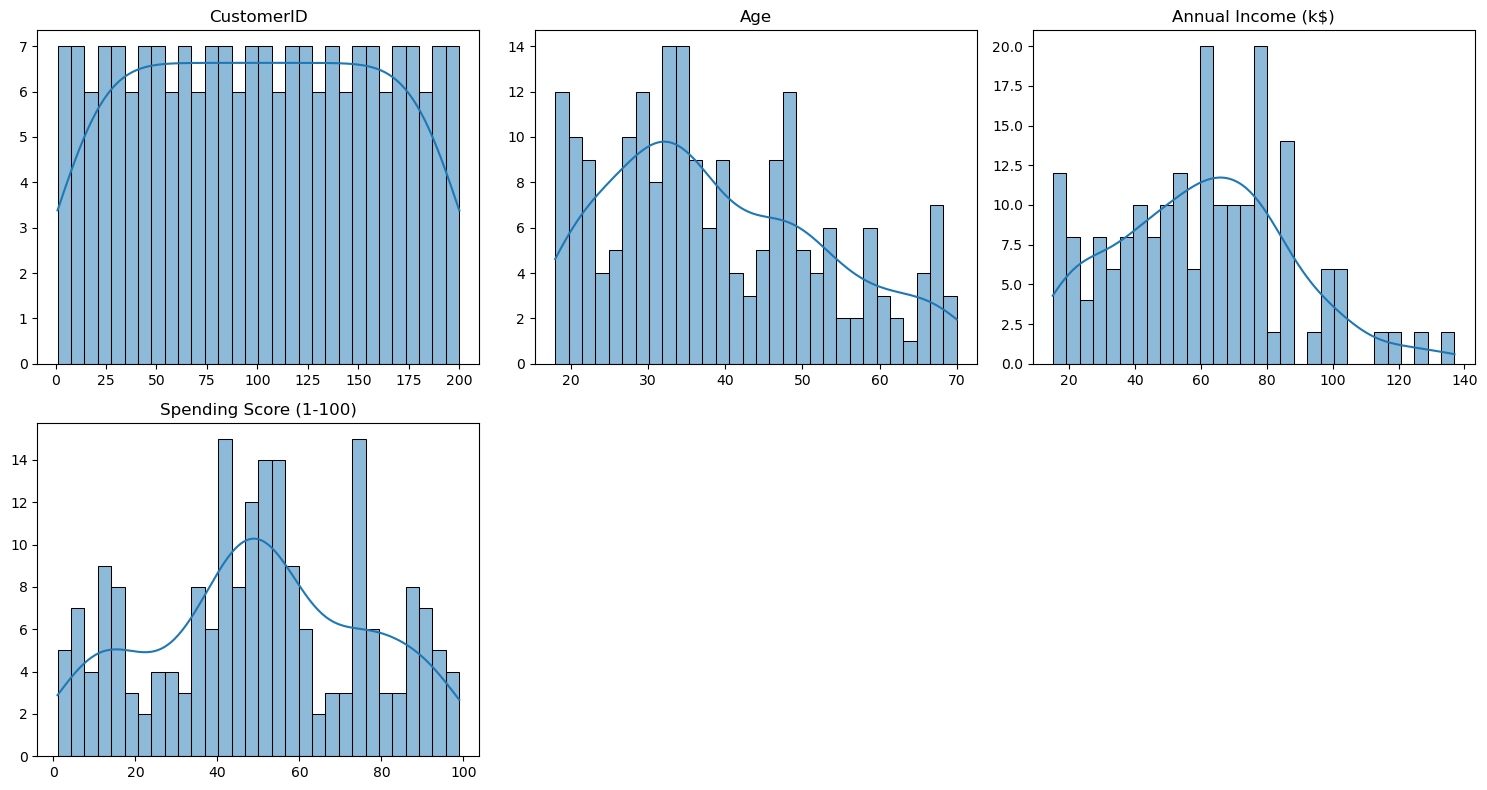

In [8]:
plot_all_histograms(df)

In [9]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
label_encoder = LabelEncoder()

In [12]:
df['Gender'] = label_encoder.fit_transform(df['Gender'])

In [13]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [14]:
df = df.drop('CustomerID',axis=1)

In [15]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
scaler = MinMaxScaler()
df_scaler = scaler.fit_transform(df)

In [18]:
df_scaler

array([[1.        , 0.01923077, 0.        , 0.3877551 ],
       [1.        , 0.05769231, 0.        , 0.81632653],
       [0.        , 0.03846154, 0.00819672, 0.05102041],
       [0.        , 0.09615385, 0.00819672, 0.7755102 ],
       [0.        , 0.25      , 0.01639344, 0.39795918],
       [0.        , 0.07692308, 0.01639344, 0.76530612],
       [0.        , 0.32692308, 0.02459016, 0.05102041],
       [0.        , 0.09615385, 0.02459016, 0.94897959],
       [1.        , 0.88461538, 0.03278689, 0.02040816],
       [0.        , 0.23076923, 0.03278689, 0.7244898 ],
       [1.        , 0.94230769, 0.03278689, 0.13265306],
       [0.        , 0.32692308, 0.03278689, 1.        ],
       [0.        , 0.76923077, 0.04098361, 0.14285714],
       [0.        , 0.11538462, 0.04098361, 0.7755102 ],
       [1.        , 0.36538462, 0.04098361, 0.12244898],
       [1.        , 0.07692308, 0.04098361, 0.79591837],
       [0.        , 0.32692308, 0.04918033, 0.34693878],
       [1.        , 0.03846154,

In [19]:
df = pd.DataFrame(df_scaler,columns=df.columns)

In [20]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


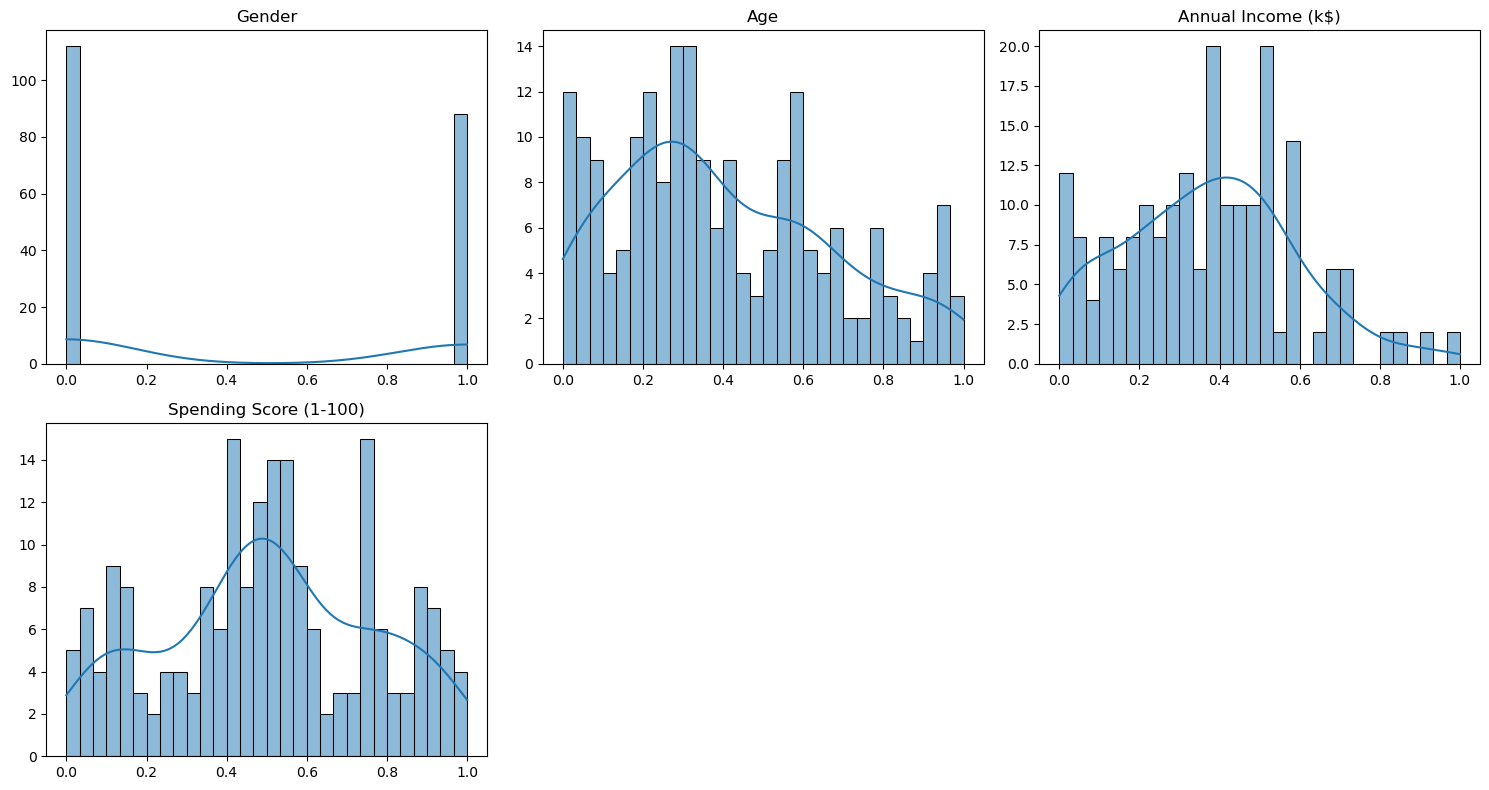

In [21]:
plot_all_histograms(df)

DENDOGRAM

In [22]:
import scipy.cluster.hierarchy as sch 

In [23]:
# ==============================================================
# scipy.cluster.hierarchy (sch) Ne İşe Yarar?
# ==============================================================
# Ne İşe Yarar: Hiyerarşik kümeleme yapmak ve küme birleşmelerini
# görselleştiren Dendrogram (ağaç grafiği) çizmek için kullanılır[cite: 9].

# Nerede Kullanılır:
# 1. Dendrogram grafiği çizip ideal küme (K) sayısını gözle tespit etmekte[cite: 9].
# 2. Bağlantı matrisi (linkage matrix) oluşturup uzaklıkları hesaplamakta[cite: 9].

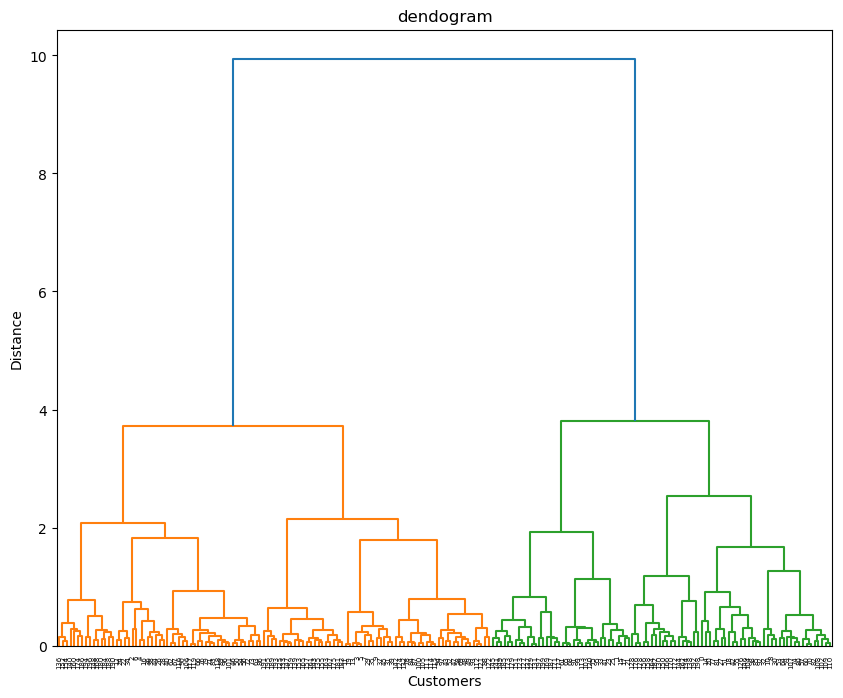

In [24]:
plt.figure(1,figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(df,method='ward'))
plt.title('dendogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

In [25]:
# ==============================================================
# Dendrogram'da Çizgi Uzunluğunu Seçme Mantığı
# ==============================================================

# 1. EN BÜYÜK DİKEY BOŞLUĞU BUL:
# - Grafiğe bak: Y ekseninde 4 ile 10 arasında (Mavi çizgilerin olduğu bölge) 
#   HİÇBİR YATAY BİRLEŞME YOK[cite: 12]. 
# - Yükseklik farkı: 10 - 4 = 6 birim dikey mesafe var (En uzun boşluk burası)[cite: 12].

# 2. NEDEN TURUNCU VEYA YEŞİLLER DEĞİL?
# - Turuncu ve yeşil çizgiler y=2 ile y=3.8 arasında sürekli yatay çizgilerle bölünüyor[cite: 12].
# - Onların dikey boyu sadece 1-1.5 birim civarında (yani kısa dikey mesafeler)[cite: 12].

# 3. YATAY KESİMİ NEREDEN ATACAKSIN?
# - O en uzun 6 birimlik boşluğun tam ortasından (örneğin y = 6 veya y = 7 seviyesinden)
#   soldan sağa düz bir çizgi çek[cite: 12].
# - O seviyede sadece 2 tane mavi dikey çizgi durduğu için İDEAL K = 2 çıkar[cite: 12].

# NOT (Alternatif Seçim):
# - Eğer "Ben veriyi daha detaylı ayırmak istiyorum" dersen, 
#   y=3 seviyesinden kesersin; orada kesilen turuncu ve yeşil dal sayısı toplamı K = 4 veya K = 5 olur[cite: 12].

cizgi uzunlukarina karar vererek kume sayimizi bulmus olucaz 

cizgilere baktigim 4 ile 6 arasinda kume secmenin daha mantikli olacagini dusunuyorum ben 

In [26]:
from sklearn.cluster import AgglomerativeClustering

In [27]:
hc = AgglomerativeClustering(n_clusters=4)

In [28]:
hc

AgglomerativeClustering(n_clusters=4)

In [29]:
y_hc = hc.fit_predict(df)

In [30]:
y_hc

array([0, 2, 3, 1, 3, 1, 3, 1, 0, 1, 0, 1, 3, 1, 0, 2, 3, 2, 0, 1, 0, 2,
       3, 2, 3, 2, 3, 0, 3, 1, 0, 1, 0, 2, 3, 1, 3, 1, 3, 1, 3, 2, 0, 1,
       3, 1, 3, 1, 1, 1, 3, 0, 1, 0, 3, 0, 3, 0, 1, 0, 0, 2, 3, 3, 0, 2,
       3, 3, 2, 1, 0, 3, 3, 3, 0, 2, 3, 0, 1, 3, 0, 0, 0, 3, 1, 0, 3, 1,
       1, 3, 3, 2, 0, 1, 1, 2, 3, 1, 0, 2, 1, 3, 0, 2, 0, 1, 3, 0, 0, 0,
       0, 1, 1, 2, 1, 1, 3, 3, 3, 3, 2, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2,
       1, 1, 0, 1, 3, 2, 0, 1, 3, 2, 1, 1, 0, 2, 0, 1, 3, 2, 0, 2, 3, 1,
       3, 1, 0, 1, 0, 1, 3, 1, 0, 1, 0, 1, 0, 1, 3, 2, 0, 2, 0, 2, 3, 1,
       0, 2, 0, 2, 3, 1, 0, 1, 3, 2, 3, 2, 3, 1, 3, 1, 0, 1, 3, 1, 3, 2,
       0, 2])

In [31]:
df['cluster'] = pd.DataFrame(y_hc)

In [32]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3


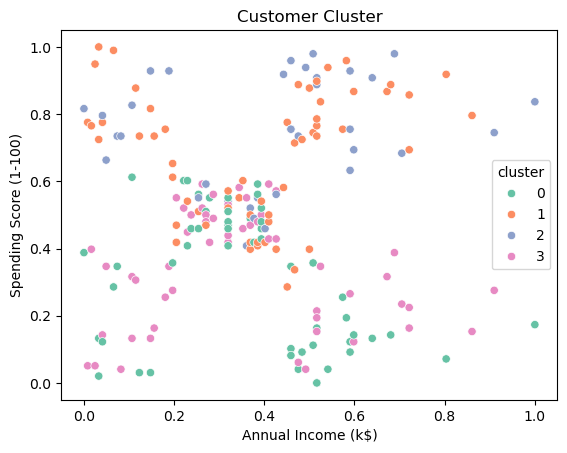

In [33]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',palette='Set2')
plt.title('Customer Cluster')
plt.show()

kumelenme cok iyi durmuyor her seyden her yerde var 

In [34]:
from sklearn.metrics import silhouette_score

In [35]:
print(silhouette_score(df,y_hc))

0.7143503785893516


verimiz cok istedigimiz gibi olmadigi icin kendim bir df olusturacam ve sonuclara bakicam 

In [36]:
X = df[['Annual Income (k$)','Spending Score (1-100)']].copy()

In [37]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959


In [38]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)
X['cluster'] = y_hc

In [39]:
X.head()

,Annual Income (k$),Spending Score (1-100),cluster
0,0.000000,0.387755,4
1,0.000000,0.816327,3
2,0.008197,0.051020,4
3,0.008197,0.775510,3
4,0.016393,0.397959,4


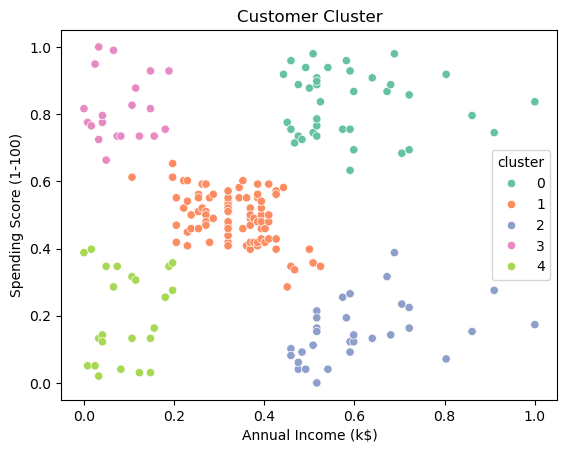

In [40]:
sns.scatterplot(data=X,x='Annual Income (k$)',y='Spending Score (1-100)',hue='cluster',palette='Set2')
plt.title('Customer Cluster')
plt.show()

suanda kumelerimiz biraz daha iyi duruma geldi ama bu oldu anlamina gelmez cunklu biz 2 boyutlu olarak goruyoruz belki 4 boyutlu olrak gorsek ilk yaptigimiz grafik daha iyi olabilirdi bizim icin bundan dolayi genede silhouette scoruna bakmamiz lazim

In [41]:
print(silhouette_score(X,y_hc))

0.8508773413981672


In [42]:
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score

In [47]:
df = pd.read_csv('27-mall_customers.csv')
df = df.drop('CustomerID',axis=1)
le= LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features_2d = ['Annual Income (k$)','Spending Score (1-100)']
features_3d = ['Age','Annual Income (k$)','Spending Score (1-100)']
features_4d = ['Gender','Age','Annual Income (k$)','Spending Score (1-100)']

for feats in [features_2d,features_3d,features_4d]:
    X=df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5)
    y_hc = hc.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled,y_hc)
    db = davies_bouldin_score(X_scaled,y_hc)
    ch = calinski_harabasz_score(X_scaled,y_hc)

    print(f'\n features:{feats}')
    print(sil)
    print(db)
    print(ch)


 features:['Annual Income (k$)', 'Spending Score (1-100)']
0.5582698727196419
0.5734519252471812
258.97400737720704

 features:['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
0.3955454334726547
0.8746143334035464
123.99070840826577

 features:['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
0.35032447507156306
1.0941951795238567
163.46602356383625


K-MEANS

In [48]:
from sklearn.cluster import KMeans

In [51]:
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('27-mall_customers.csv')
df = df.drop('CustomerID',axis=1)
le= LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features_2d = ['Annual Income (k$)','Spending Score (1-100)']
features_3d = ['Age','Annual Income (k$)','Spending Score (1-100)']
features_4d = ['Gender','Age','Annual Income (k$)','Spending Score (1-100)']

for feats in [features_2d,features_3d,features_4d]:
    X=df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_hc = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled,y_hc)
    db = davies_bouldin_score(X_scaled,y_hc)
    ch = calinski_harabasz_score(X_scaled,y_hc)

    print(f'\n features:{feats}')
    print(sil)
    print(db)
    print(ch)


 features:['Annual Income (k$)', 'Spending Score (1-100)']
0.558627081394975
0.5668527515455375
264.5866380358972

 features:['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
0.40588120152587825
0.9361270042587133
126.05974459737251

 features:['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
0.3562130426663029
1.0917204381203722
158.21862430993386


K-Means biraz daha iyi duruyor ama cokda yii degil buyuk bir fark yok

In [53]:
######################################################


SİLÜET (SILHOUETTE) SKORU NOTU

K-Means / Hiyerarşik Kümeleme yaparken:
1. Kümeleri (y_hc / labels) ÖLÇEKLENMİŞ VERİ (X_scaled) ile buluruz.
2. Gerçek Silüet Skoru hesaplanırken uzaklıklar ORİJİNAL/HAM VERİ (X)
   üzerinden değerlendirilmelidir.

--- YANLIŞ / YANILTICI KULLANIM ---
sil = silhouette_score(X_scaled, y_hc)  Sıkıştırılmış ölçek skor yanılsaması yaratır

--- DOĞRU / GERÇEK KULLANIM ---
sil_real = silhouette_score(X, y_hc)    Orijinal ölçekteki gerçek ayrışma skoru

print(f"Gerçek Silhouette Skoru: {sil_real:.4f}")

Onemli bir nottur gercek silhouette scoru istedigimiz zaman bunu unutmamaiz gerekir 